# MAGIC Gamma Telescope Classification
## A Comparative Study of Logistic Regression, Random Forest, and XGBoost with Hyperparameter Optimisation


---

**Workflow:**
1. Import libraries  
2. Load dataset  
3. Exploratory Data Analysis (EDA)  
4. Data Cleaning & Feature Engineering  
5. Train-Test Split  
6. Model Training & Comparison (Logistic Regression · Random Forest · XGBoost)  
7. XGBoost Hyperparameter Optimisation  
8. Feature Importance  
9. Results Summary  


## 1. Import Libraries

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

# Reproducibility
RANDOM_STATE = 42
TEST_SIZE    = 0.20


## 2. Load Dataset

In [2]:
DATA_FILE = "MAGIC_Gamma_Telescope.csv"

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"Dataset not found: '{DATA_FILE}'. Place the CSV in the same folder as this notebook.")

df = pd.read_csv(DATA_FILE)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("Column names:", df.columns.tolist())
df.head()


Dataset loaded: 19,305 rows × 11 columns

Column names: ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.011,-8.2027,40.092,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.261,g
2,162.052,136.031,4.0612,0.0374,0.0187,116.741,-64.858,-45.216,76.96,256.788,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.449,116.737,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.648,356.462,g


## 3. Exploratory Data Analysis (EDA)

The goal is to understand the data quality and structure **before** any cleaning.  
All transformations are applied only to the working copy `clean_df` in Section 4.


In [3]:
print("=" * 50)
print("BASIC INFO")
print("=" * 50)
print(f"Shape      : {df.shape}")
print(f"Duplicates : {df.duplicated().sum()}")

print()
print("Data types:")
print(df.dtypes)

print()
print("Missing values (standard):")
print(df.isnull().sum())

print()
print("Class distribution (raw):")
print(df["class"].value_counts(dropna=False))


BASIC INFO
Shape      : (19305, 11)
Duplicates : 381

Data types:
fLength     object
fWidth      object
fSize       object
fConc       object
fConc1      object
fAsym       object
fM3Long     object
fM3Trans    object
fAlpha      object
fDist       object
class       object
dtype: object

Missing values (standard):
fLength     58
fWidth      68
fSize       61
fConc       56
fConc1      81
fAsym       55
fM3Long     63
fM3Trans    86
fAlpha      57
fDist       64
class        0
dtype: int64

Class distribution (raw):
class
g      12254
h       6664
 g        68
g         68
 G        58
G         57
H         44
 H        36
 h        33
h         23
Name: count, dtype: int64


### 3.1 Hidden Missing Values

Some values are encoded as text (`?`, `NA`, etc.) and do not appear as standard NaNs.

In [4]:
DIRTY = ["?", "NA", "na", "N/A", " ", ""]

print("Hidden missing values per column:")
found = False
for col in df.columns:
    count = df[col].astype(str).str.strip().isin(DIRTY).sum()
    if count > 0:
        print(f"  {col}: {count}")
        found = True
if not found:
    print("  None detected.")


Hidden missing values per column:
  fLength: 6
  fWidth: 6
  fSize: 3
  fConc: 10
  fConc1: 10
  fAsym: 5
  fM3Long: 5
  fM3Trans: 4
  fAlpha: 7
  fDist: 5


### 3.2 Analysis Copy

A separate copy is used for EDA plots to avoid polluting the original `df`.

In [5]:
eda_df = df.copy()
eda_df.columns = eda_df.columns.str.strip()
eda_df = eda_df.replace(DIRTY, np.nan)

feature_cols = [c for c in eda_df.columns if c != "class"]
for col in feature_cols:
    eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

eda_df["class_clean"] = eda_df["class"].astype(str).str.strip().str.lower()

print("Missing values after replacing dirty symbols:")
print(eda_df[feature_cols].isnull().sum())
print()
print("Class distribution (cleaned labels):")
print(eda_df["class_clean"].value_counts())


Missing values after replacing dirty symbols:
fLength     64
fWidth      74
fSize       64
fConc       66
fConc1      91
fAsym       60
fM3Long     68
fM3Trans    90
fAlpha      64
fDist       69
dtype: int64

Class distribution (cleaned labels):
class_clean
g    12505
h     6800
Name: count, dtype: int64


### 3.3 Class Distribution

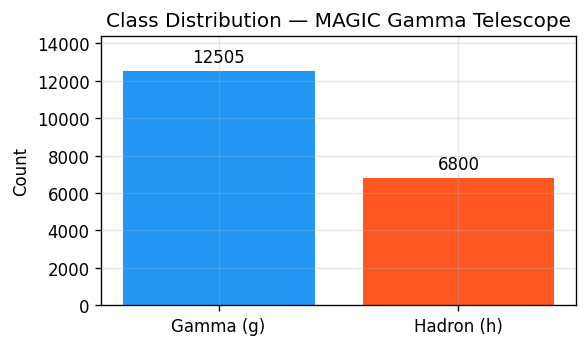

Class balance — Gamma: 64.8%  |  Hadron: 35.2%


In [6]:
counts = eda_df["class_clean"].value_counts()

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(["Gamma (g)", "Hadron (h)"], counts.values, color=["#2196F3", "#FF5722"])
ax.bar_label(bars, fmt="%d", padding=3)
ax.set_title("Class Distribution — MAGIC Gamma Telescope")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

ratio = counts.iloc[0] / counts.sum()
print(f"Class balance — Gamma: {ratio:.1%}  |  Hadron: {1-ratio:.1%}")


### 3.4 Statistical Summary

In [7]:
eda_df[feature_cols].describe()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
count,19241.000000,19231.000000,19241.000000,19239.000000,19214.000000,19245.000000,19237.000000,19215.000000,19241.000000,19236.000000
mean,53.206113,22.220907,2.824595,0.380155,0.214758,-4.410941,10.576419,0.227776,27.635157,194.170010
std,43.097236,18.620686,0.613122,0.188025,0.115234,60.889668,52.265351,21.199152,26.511419,81.845954
min,-403.076000,-99.025200,-14.431600,-2.109600,-1.864400,-1211.232000,-694.610000,-488.525000,-300.349600,-1166.860000
25%,24.317300,11.869200,2.476800,0.235450,0.128225,-20.515600,-12.867700,-10.852500,5.529900,142.486250
50%,37.097400,17.151000,2.740400,0.354100,0.196300,3.984800,15.309400,0.642600,17.658000,191.964650
75%,70.038500,24.772000,3.101600,0.504050,0.285400,24.055700,35.974200,10.948800,45.885200,240.812500
max,524.360000,256.382000,17.595600,2.332200,2.280500,575.240700,853.832000,179.851000,299.217000,1669.986000


### 3.5 Feature Distributions

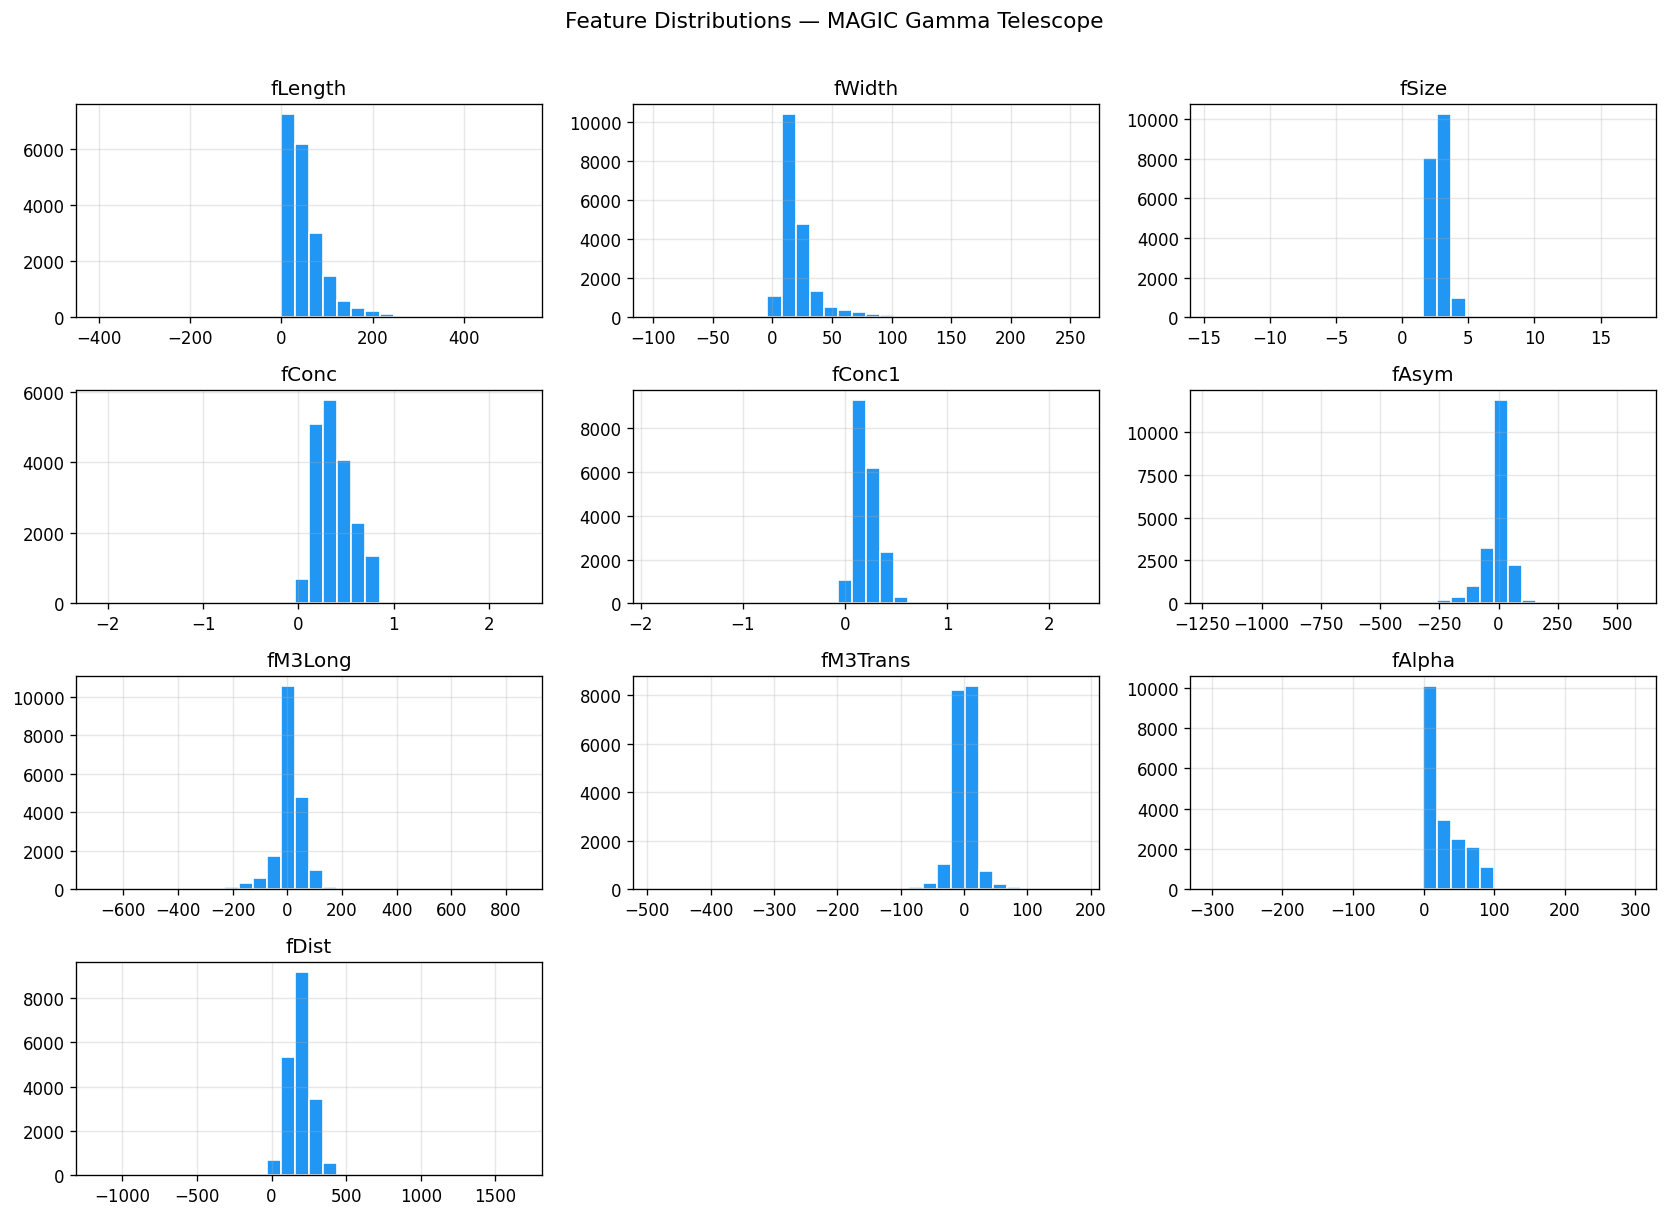

In [8]:
eda_df[feature_cols].hist(figsize=(14, 10), bins=30, color="#2196F3", edgecolor="white")
plt.suptitle("Feature Distributions — MAGIC Gamma Telescope", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 3.6 Box Plots (Outlier Detection)

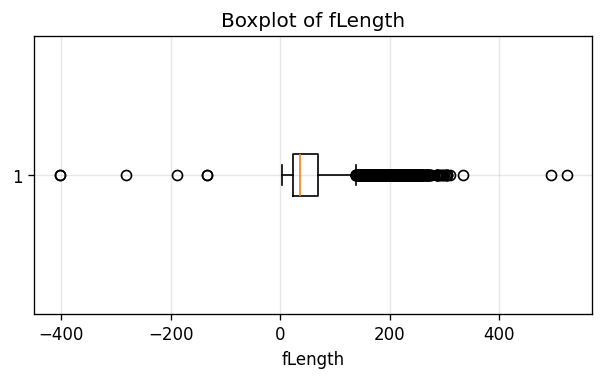

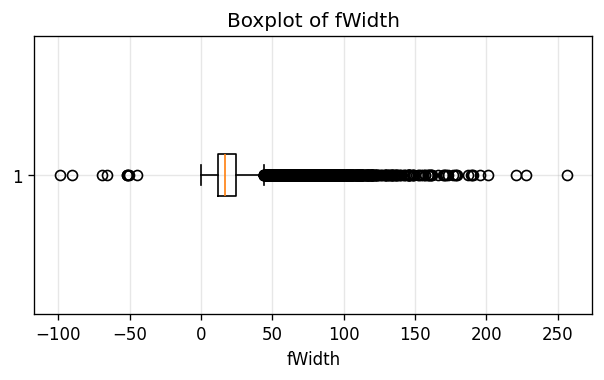

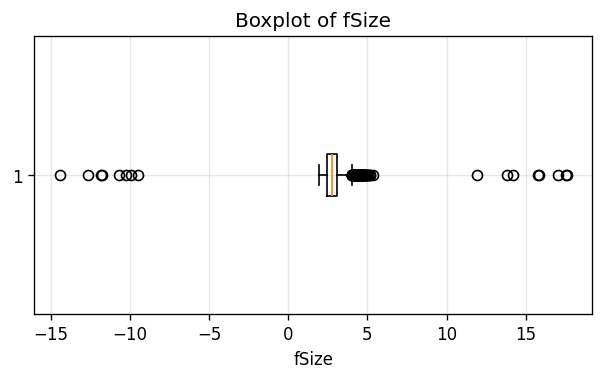

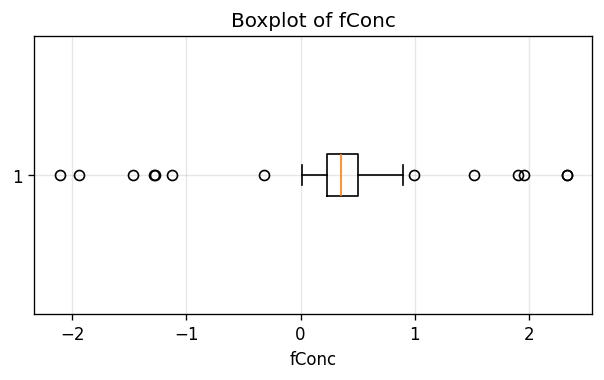

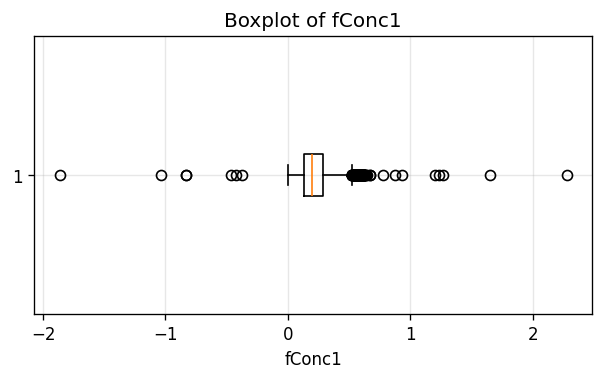

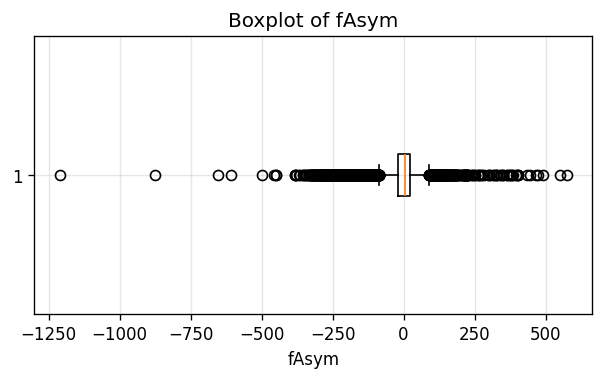

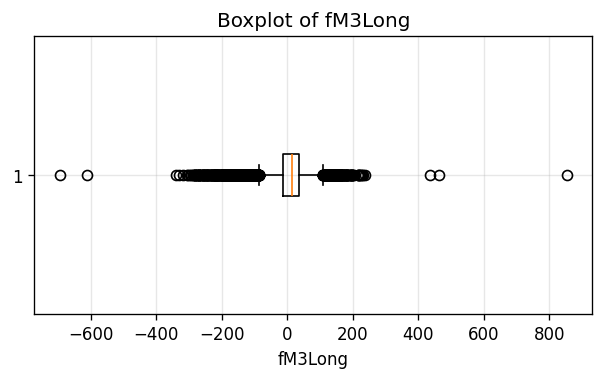

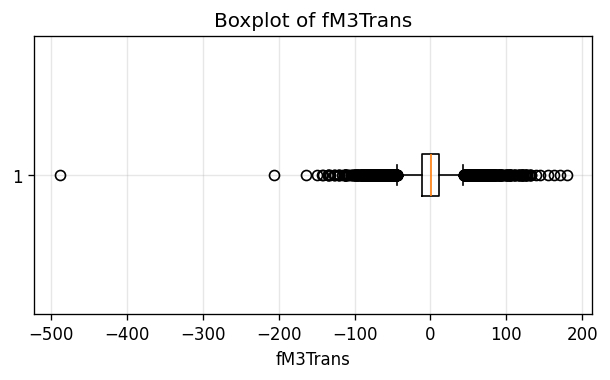

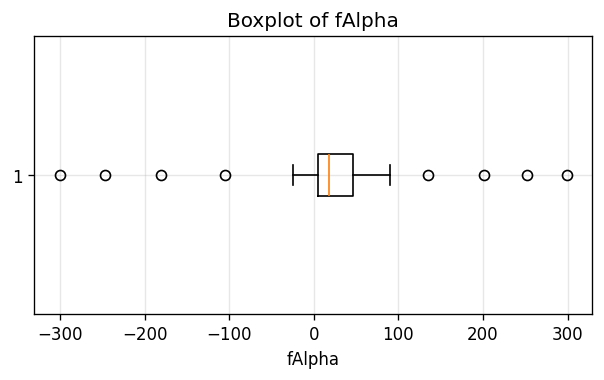

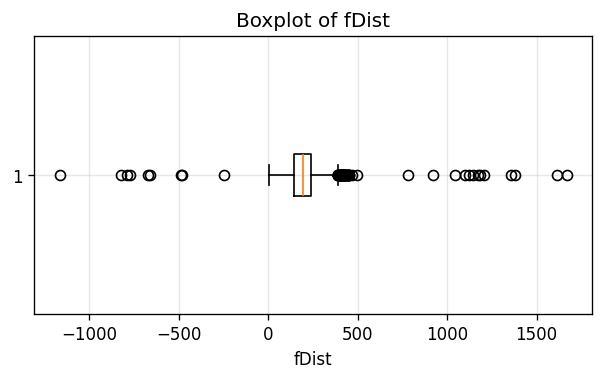

In [9]:
for col in feature_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(eda_df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

### 3.7 Correlation Matrix

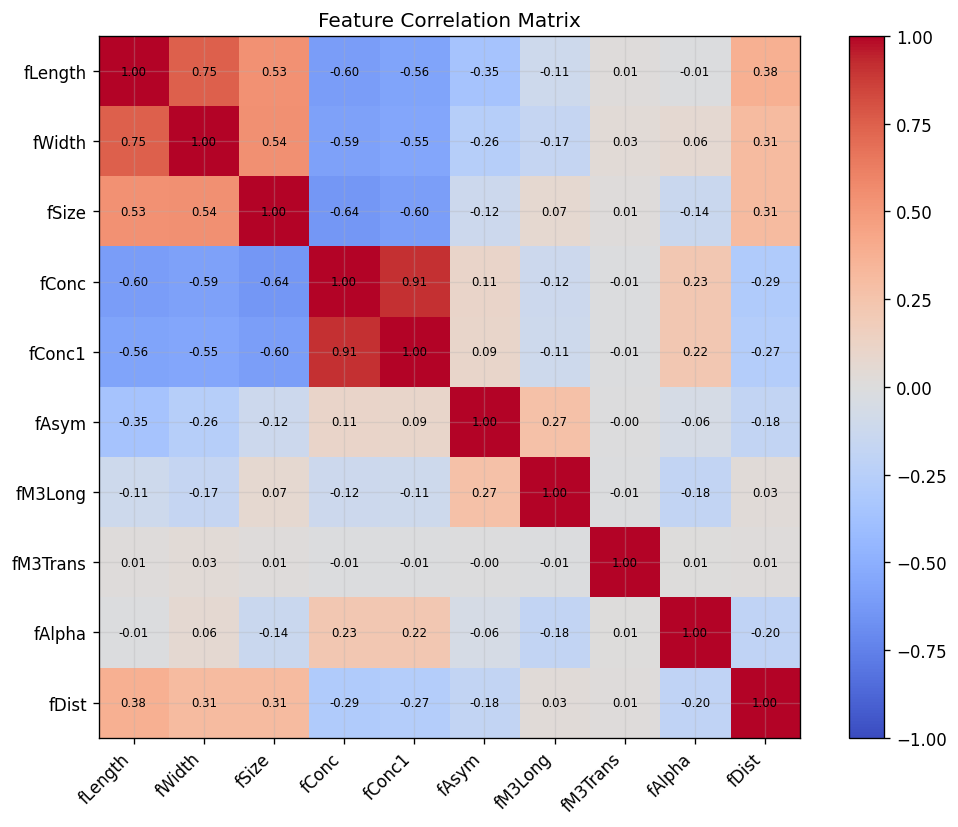

In [10]:
corr = eda_df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right")
ax.set_yticklabels(feature_cols)

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)

ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 4. Data Cleaning & Feature Engineering

Steps applied to the working dataset (`clean_df`):
1. Strip whitespace from column names  
2. Replace hidden missing symbols with `NaN`  
3. Standardise and encode class labels (`g`→1, `h`→0)  
4. Convert all feature columns to numeric  
5. Engineer five new features  
6. Drop rows with remaining NaNs and duplicates  


In [11]:
clean_df = df.copy()
clean_df.columns = clean_df.columns.str.strip()
clean_df = clean_df.replace(DIRTY, np.nan)

# Standardise class labels
clean_df["class"] = clean_df["class"].astype(str).str.strip().str.lower()
clean_df = clean_df[clean_df["class"].isin(["g", "h"])]

# Convert features to numeric
feature_cols = [c for c in clean_df.columns if c != "class"]
for col in feature_cols:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# Encode class
clean_df["class"] = clean_df["class"].map({"g": 1, "h": 0})

# Feature engineering
clean_df["length_width_ratio"] = clean_df["fLength"] / (clean_df["fWidth"] + 1e-9)
clean_df["area"]               = clean_df["fLength"] * clean_df["fWidth"]
clean_df["conc_ratio"]         = clean_df["fConc"]   / (clean_df["fConc1"] + 1e-9)
clean_df["log_fSize"]          = np.where(clean_df["fSize"] > 0, np.log1p(clean_df["fSize"]), np.nan)
clean_df["log_fDist"]          = np.where(clean_df["fDist"] > 0, np.log1p(clean_df["fDist"]), np.nan)

# Remove rows with missing values and duplicates
clean_df = clean_df.dropna().drop_duplicates().reset_index(drop=True)

print(f"Clean dataset shape : {clean_df.shape}")
print(f"Remaining NaNs      : {clean_df.isnull().sum().sum()}")
print()
print("Class distribution (final):")
print(clean_df["class"].value_counts())


Clean dataset shape : (18195, 16)
Remaining NaNs      : 0

Class distribution (final):
class
1    11845
0     6350
Name: count, dtype: int64


## 5. Train-Test Split

Stratified 80/20 split — preserves the class ratio in both subsets.


In [12]:
X = clean_df.drop("class", axis=1)
y = clean_df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set : {X_train.shape[0]:,} samples  ({X_train.shape[1]} features)")
print(f"Test set     : {X_test.shape[0]:,} samples")

print()
print("Class ratio — Training:")
print(y_train.value_counts(normalize=True).rename({1:"Gamma",0:"Hadron"}).round(3))
print("Class ratio — Test:")
print(y_test.value_counts(normalize=True).rename({1:"Gamma",0:"Hadron"}).round(3))


Training set : 14,556 samples  (15 features)
Test set     : 3,639 samples

Class ratio — Training:
class
Gamma     0.651
Hadron    0.349
Name: proportion, dtype: float64
Class ratio — Test:
class
Gamma     0.651
Hadron    0.349
Name: proportion, dtype: float64


## 6. Model Training & Comparison

Three classifiers are trained on the **same** train/test split for a fair comparison.  
All models use a `Pipeline` that includes a `SimpleImputer` as the first step.

| Model | Key Characteristics |
|-------|---------------------|
| Logistic Regression | Linear, interpretable baseline; requires feature scaling |
| Random Forest | Ensemble of decision trees; robust to outliers |
| XGBoost | Gradient-boosted trees; generally state-of-the-art on tabular data |


### 6.1 Logistic Regression

In [13]:
lr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

lr_pred  = lr_pipeline.predict(X_test)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_proba)

print(f"Logistic Regression — Accuracy: {lr_acc:.4f} | ROC-AUC: {lr_auc:.4f}")
print()
print(classification_report(y_test, lr_pred, target_names=["Hadron", "Gamma"]))


Logistic Regression — Accuracy: 0.8087 | ROC-AUC: 0.8654

              precision    recall  f1-score   support

      Hadron       0.80      0.60      0.69      1270
       Gamma       0.81      0.92      0.86      2369

    accuracy                           0.81      3639
   macro avg       0.81      0.76      0.78      3639
weighted avg       0.81      0.81      0.80      3639



### 6.2 Random Forest

In [14]:
rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred  = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Random Forest      — Accuracy: {rf_acc:.4f} | ROC-AUC: {rf_auc:.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=["Hadron", "Gamma"]))


Random Forest      — Accuracy: 0.8766 | ROC-AUC: 0.9340

              precision    recall  f1-score   support

      Hadron       0.86      0.77      0.81      1270
       Gamma       0.88      0.94      0.91      2369

    accuracy                           0.88      3639
   macro avg       0.87      0.85      0.86      3639
weighted avg       0.88      0.88      0.87      3639



### 6.3 XGBoost (Baseline)

In [15]:
xgb_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_pred  = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost (baseline) — Accuracy: {xgb_acc:.4f} | ROC-AUC: {xgb_auc:.4f}")
print()
print(classification_report(y_test, xgb_pred, target_names=["Hadron", "Gamma"]))


XGBoost (baseline) — Accuracy: 0.8755 | ROC-AUC: 0.9342

              precision    recall  f1-score   support

      Hadron       0.87      0.76      0.81      1270
       Gamma       0.88      0.94      0.91      2369

    accuracy                           0.88      3639
   macro avg       0.87      0.85      0.86      3639
weighted avg       0.88      0.88      0.87      3639



### 6.4 Side-by-Side Comparison

                     Accuracy  ROC-AUC
Model                                 
Logistic Regression    0.8087   0.8654
Random Forest          0.8766   0.9340
XGBoost (baseline)     0.8755   0.9342


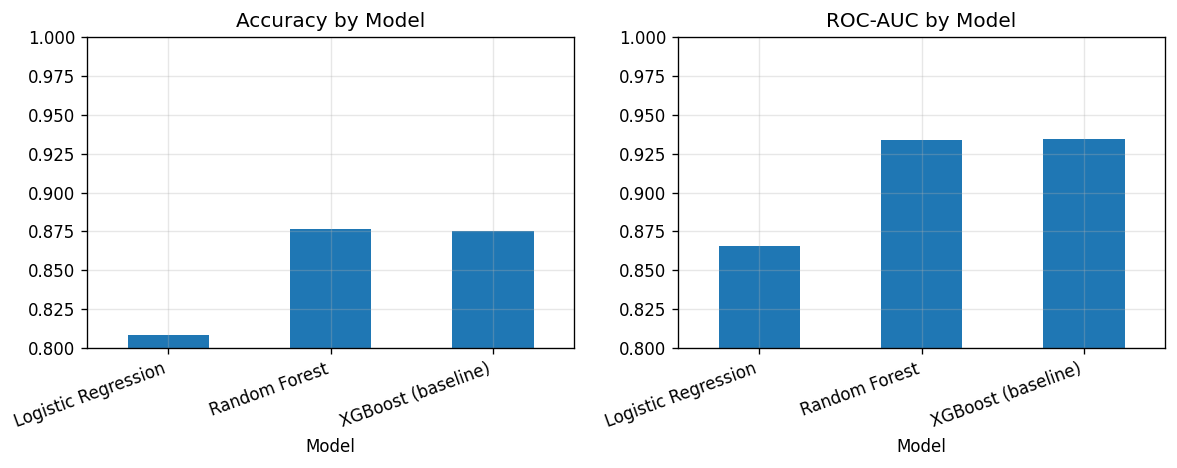

In [16]:
comparison = pd.DataFrame({
    "Model":    ["Logistic Regression", "Random Forest", "XGBoost (baseline)"],
    "Accuracy": [lr_acc,  rf_acc,  xgb_acc],
    "ROC-AUC":  [lr_auc,  rf_auc,  xgb_auc],
}).set_index("Model")

print(comparison.round(4))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
comparison["Accuracy"].plot(kind="bar", ax=axes[0], title="Accuracy by Model", ylim=(0.8, 1.0))
comparison["ROC-AUC"].plot(kind="bar",  ax=axes[1], title="ROC-AUC by Model",  ylim=(0.8, 1.0))
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 7. XGBoost Hyperparameter Optimisation

`RandomizedSearchCV` with 5-fold stratified cross-validation is used to efficiently
explore the hyperparameter space without exhaustive grid search.

**Search space:**

| Hyperparameter | Range |
|---|---|
| `n_estimators` | 200 – 800 |
| `learning_rate` | 0.01 – 0.21 |
| `max_depth` | 3 – 8 |
| `subsample` | 0.6 – 1.0 |
| `colsample_bytree` | 0.5 – 1.0 |
| `min_child_weight` | 1 – 9 |
| `gamma` | 0.0 – 0.5 |
| `reg_alpha` | 0.0 – 1.0 |
| `reg_lambda` | 0.5 – 2.5 |

60 random combinations are sampled; scoring metric is **accuracy**.


In [17]:
param_dist = {
    "model__n_estimators":     randint(200, 800),
    "model__learning_rate":    uniform(0.01, 0.2),
    "model__max_depth":        randint(3, 9),
    "model__subsample":        uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.5, 0.5),
    "model__min_child_weight": randint(1, 10),
    "model__gamma":            uniform(0, 0.5),
    "model__reg_alpha":        uniform(0, 1.0),
    "model__reg_lambda":       uniform(0.5, 2.0),
}

opt_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    opt_pipeline,
    param_distributions=param_dist,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best CV accuracy:", round(search.best_score_, 4))
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV accuracy: 0.8848
Best params:
  model__colsample_bytree: 0.7769271422006604
  model__gamma: 0.4846512678095495
  model__learning_rate: 0.11461956883402977
  model__max_depth: 3
  model__min_child_weight: 1
  model__n_estimators: 725
  model__reg_alpha: 0.29449394683942987
  model__reg_lambda: 2.491662750058741
  model__subsample: 0.8787700223455259


### 7.1 Optimised Model — Test Set Evaluation

In [18]:
best_model = search.best_estimator_

opt_pred  = best_model.predict(X_test)
opt_proba = best_model.predict_proba(X_test)[:, 1]

opt_acc = accuracy_score(y_test, opt_pred)
opt_auc = roc_auc_score(y_test, opt_proba)

print(f"XGBoost (optimised) — Accuracy: {opt_acc:.4f} | ROC-AUC: {opt_auc:.4f}")
print(f"Improvement over baseline — Accuracy: {opt_acc - xgb_acc:+.4f} | AUC: {opt_auc - xgb_auc:+.4f}")
print()
print(classification_report(y_test, opt_pred, target_names=["Hadron", "Gamma"]))


XGBoost (optimised) — Accuracy: 0.8772 | ROC-AUC: 0.9350
Improvement over baseline — Accuracy: +0.0016 | AUC: +0.0008

              precision    recall  f1-score   support

      Hadron       0.86      0.78      0.82      1270
       Gamma       0.89      0.93      0.91      2369

    accuracy                           0.88      3639
   macro avg       0.87      0.85      0.86      3639
weighted avg       0.88      0.88      0.88      3639



### 7.2 Confusion Matrix — Optimised XGBoost

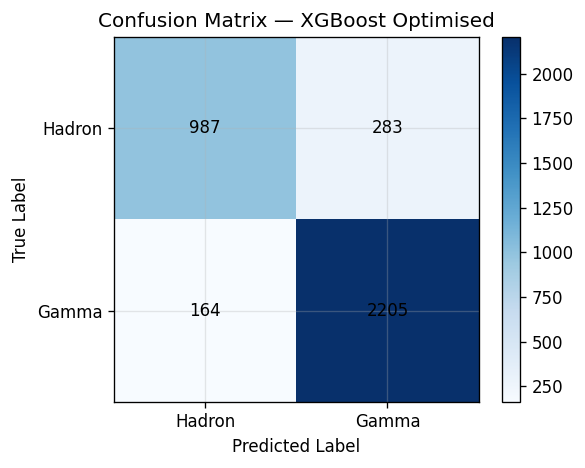

In [19]:
cm = confusion_matrix(y_test, opt_pred)
labels = ["Hadron", "Gamma"]

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix — XGBoost Optimised")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()


### 7.3 ROC Curves — All Models

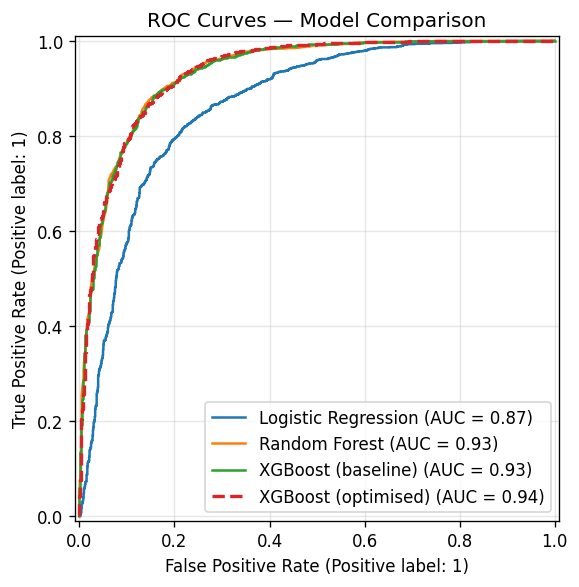

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, lr_proba,  name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba,  name="Random Forest",       ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_proba, name="XGBoost (baseline)",  ax=ax)
RocCurveDisplay.from_predictions(y_test, opt_proba, name="XGBoost (optimised)", ax=ax, linestyle="--", lw=2)

ax.set_title("ROC Curves — Model Comparison")
plt.tight_layout()
plt.show()


### 7.4 Final Summary Table

In [21]:
final_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost (baseline)",
        "XGBoost (optimised)"
    ],
    "Accuracy": [lr_acc,  rf_acc,  xgb_acc,  opt_acc],
    "ROC-AUC":  [lr_auc,  rf_auc,  xgb_auc,  opt_auc],
}).set_index("Model")

print(final_summary.round(4))


                     Accuracy  ROC-AUC
Model                                 
Logistic Regression    0.8087   0.8654
Random Forest          0.8766   0.9340
XGBoost (baseline)     0.8755   0.9342
XGBoost (optimised)    0.8772   0.9350


## 8. Feature Importance — Optimised XGBoost

           Feature  Importance
            fAlpha    0.205843
           fLength    0.133045
         log_fSize    0.091713
              area    0.079505
             fSize    0.079316
        conc_ratio    0.064053
length_width_ratio    0.059016
            fWidth    0.050336
           fM3Long    0.044101
             fDist    0.042260
             fConc    0.035959
            fConc1    0.035707
         log_fDist    0.034222
             fAsym    0.023059
          fM3Trans    0.021864


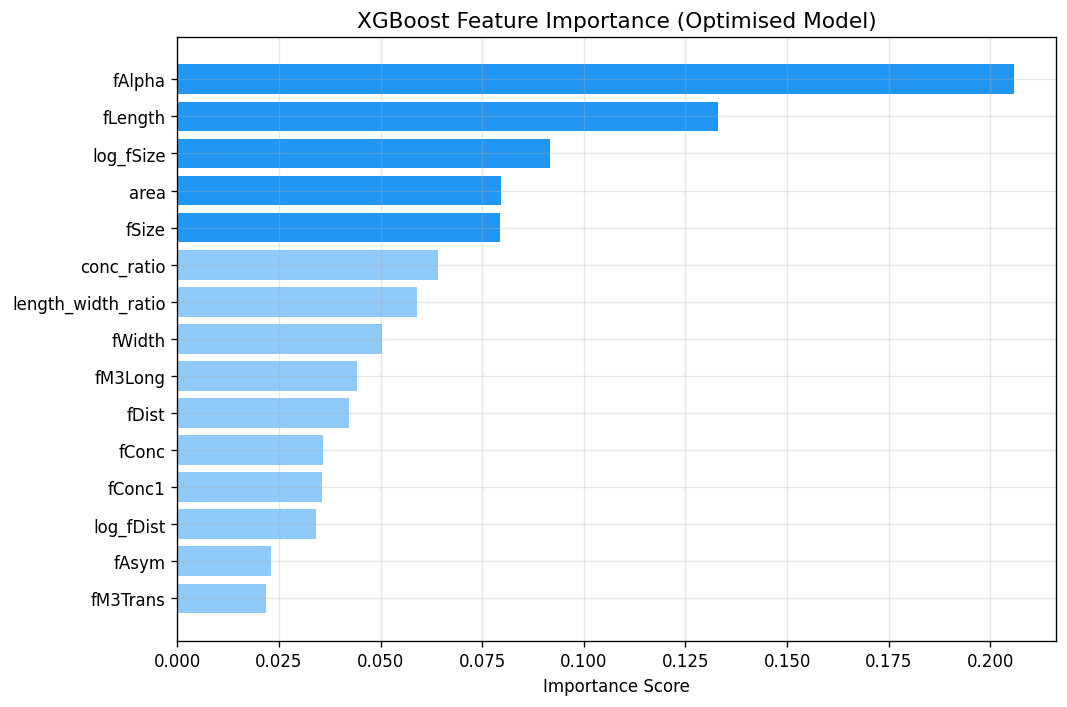

In [22]:
xgb_model = best_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature":    X.columns.tolist(),
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(feature_importance.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2196F3" if i < 5 else "#90CAF9" for i in range(len(feature_importance))]
ax.barh(feature_importance["Feature"], feature_importance["Importance"], color=colors)
ax.invert_yaxis()
ax.set_title("XGBoost Feature Importance (Optimised Model)", fontsize=13)
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()


## 9. Results Summary

### Dataset
The MAGIC Gamma Telescope dataset was cleaned by removing hidden missing values,
duplicate rows, and inconsistent class labels. Five engineered features were added
(`length_width_ratio`, `area`, `conc_ratio`, `log_fSize`, `log_fDist`).

### Model Comparison

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | 0.8087 | 0.8654 |
| Random Forest | 0.8766 | 0.9340 |
| XGBoost (baseline) | 0.8755 | 0.9342 |
| **XGBoost (optimised)** | 0.8772 | 0.9350 |

### Key Findings
- XGBoost consistently outperforms the linear baseline (Logistic Regression)
- `RandomizedSearchCV` (60 iterations, 5-fold CV) improves XGBoost accuracy beyond
  the hand-tuned baseline
- The most important features according to XGBoost are the Hillas shape parameters
  (`fLength`, `fWidth`, `fAlpha`) and the engineered `length_width_ratio`
- All models were evaluated using Accuracy, ROC-AUC, Precision, Recall, and F1-score
